Found 20000 files belonging to 2 classes.
Using 16000 files for training.


2026-10-02 16:22:54.592490: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Epoch 1/10
    500/Unknown 276s 546ms/step - accuracy: 0.5843 - loss: 0.6612

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


500/500 ━━━━━━━━━━━━━━━━━━━━ 300s 594ms/step - accuracy: 0.6419 - loss: 0.6210 - val_accuracy: 0.7050 - val_loss: 0.5615
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 317s 635ms/step - accuracy: 0.7243 - loss: 0.5425 - val_accuracy: 0.7540 - val_loss: 0.4891
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 298s 588ms/step - accuracy: 0.7499 - loss: 0.5051 - val_accuracy: 0.7763 - val_loss: 0.4651
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 315s 574ms/step - accuracy: 0.7766 - loss: 0.4728 - val_accuracy: 0.7908 - val_loss: 0.4550
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 283s 567ms/step - accuracy: 0.7824 - loss: 0.4520 - val_accuracy: 0.7997 - val_loss: 0.4308
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 286s 572ms/step - accuracy: 0.7976 - loss: 0.4353 - val_accuracy: 0.8155 - val_loss: 0.4054
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 294s 588ms/step - accuracy: 0.8128 - loss: 0.4116 - val_accuracy: 0.8248 - val_loss: 0.3870
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 319s 639ms/step - accuracy: 0.8224 - loss: 0.39

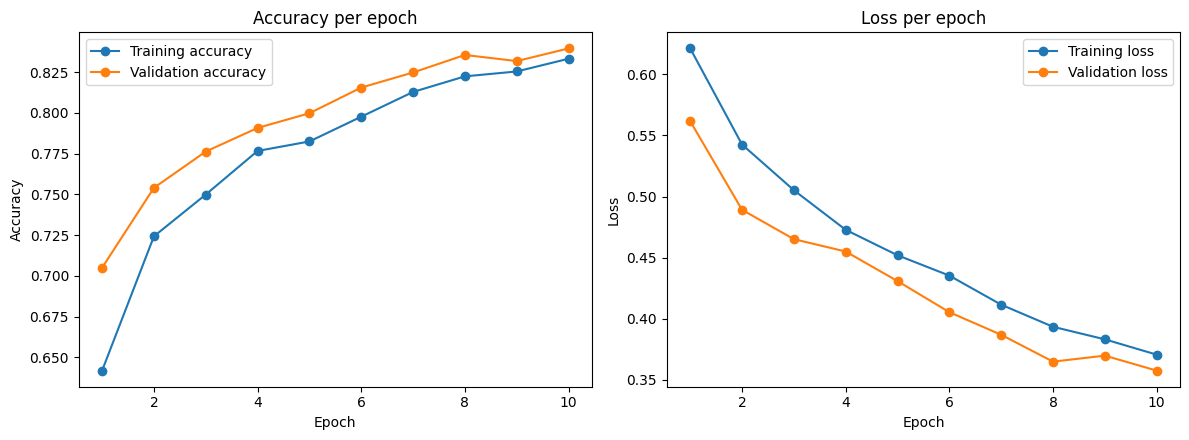

Best validation accuracy: 83.95% at epoch 10
Final train/val accuracy: 83.32% / 83.95%
Validation gain over last 3 epochs: +1.48%
Still improving.


In [1]:
import os
 
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
 
SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
AUTOTUNE = tf.data.AUTOTUNE
tf.keras.utils.set_random_seed(SEED)
 
 
def locate_train_dir():
    for root in ["/kaggle/input", "."]:
        for current, dirs, _ in os.walk(root):
            if "train" in dirs and os.path.isdir(os.path.join(current, "train", "cats")):
                return os.path.join(current, "train")
    try:
        import kagglehub
 
        folder = kagglehub.dataset_download("salader/dogs-vs-cats")
        for current, dirs, _ in os.walk(folder):
            if "train" in dirs:
                return os.path.join(current, "train")
    except Exception as err:
        raise FileNotFoundError("Dogs vs. Cats not found; add the Kaggle input.") from err
    raise FileNotFoundError("train/ folder not found.")
 
 
def load_split(directory, subset):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        validation_split=0.2, subset=subset, seed=SEED,
    )
    ds = ds.ignore_errors() if hasattr(ds, "ignore_errors") else ds.apply(
        tf.data.experimental.ignore_errors())
    return ds.prefetch(AUTOTUNE)
 
 
def build_model():
    return models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Rescaling(1.0 / 255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
 
 
def main():
    train_dir = locate_train_dir()
    train_ds = load_split(train_dir, "training")
    val_ds = load_split(train_dir, "validation")
 
    model = build_model()
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
 
    acc, val_acc = history.history["accuracy"], history.history["val_accuracy"]
    loss, val_loss = history.history["loss"], history.history["val_loss"]
    epochs = range(1, len(acc) + 1)
 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax1.plot(epochs, acc, "o-", label="Training accuracy")
    ax1.plot(epochs, val_acc, "o-", label="Validation accuracy")
    ax1.set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy per epoch")
    ax1.legend()
    ax2.plot(epochs, loss, "o-", label="Training loss")
    ax2.plot(epochs, val_loss, "o-", label="Validation loss")
    ax2.set(xlabel="Epoch", ylabel="Loss", title="Loss per epoch")
    ax2.legend()
    plt.tight_layout()
    plt.savefig("task3_accuracy_curves.png", dpi=150)
    plt.show()
 
    best = int(np.argmax(val_acc)) + 1
    gain_last3 = val_acc[-1] - val_acc[-4] if len(val_acc) >= 4 else float("nan")
    print(f"Best validation accuracy: {max(val_acc):.2%} at epoch {best}")
    print(f"Final train/val accuracy: {acc[-1]:.2%} / {val_acc[-1]:.2%}")
    print(f"Validation gain over last 3 epochs: {gain_last3:+.2%}")
    print("Plateau reached." if gain_last3 < 0.01 else "Still improving.")
    if acc[-1] - val_acc[-1] > 0.05:
        print("Training accuracy is well above validation accuracy -> overfitting.")
 
 
if __name__ == "__main__":
    main()
 